In [8]:
%load_ext autoreload
%autoreload 2
import logging
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator
from ocularrigidity.data.measurements.cohort import build_cohort
from ocularrigidity.data.measurements.cohort import get_cross_sectional_dx
from ocularrigidity.data.measurements.cohort import add_cross_sectional_dx


logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
ROOT_CARDIAC = Path("/media/clement/HD/Santiago/OcularRigidity/FullPipeline/")

df = build_cohort(root=ROOT_CARDIAC, overwrite=False)
df_cross_sectional = get_cross_sectional_dx()


class DummyContextManager:
    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        pass


d = add_cross_sectional_dx(df, df_cross_sectional, tolerance_days=365)


def one_visit_per_eye(d):
    """The cross-sectional grain: the rigidity visit nearest each Excel entry."""
    m = d[d["Diagnosis_xs"].notna()].copy()
    m["_eye"] = m["File"].astype(str) + "/" + m["Eye"].astype(str)
    m["_gap"] = m["xs_gap_days"].abs()
    return (
        m.sort_values(["_eye", "_gap"])
        .groupby("_eye", as_index=False)
        .head(1)
        .drop(columns=["_eye", "_gap"])
    )


matched = d[d["Diagnosis_xs"].notna()]  # 156 rows
merged = one_visit_per_eye(matched)

cm = plt.xkcd
cm = DummyContextManager


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


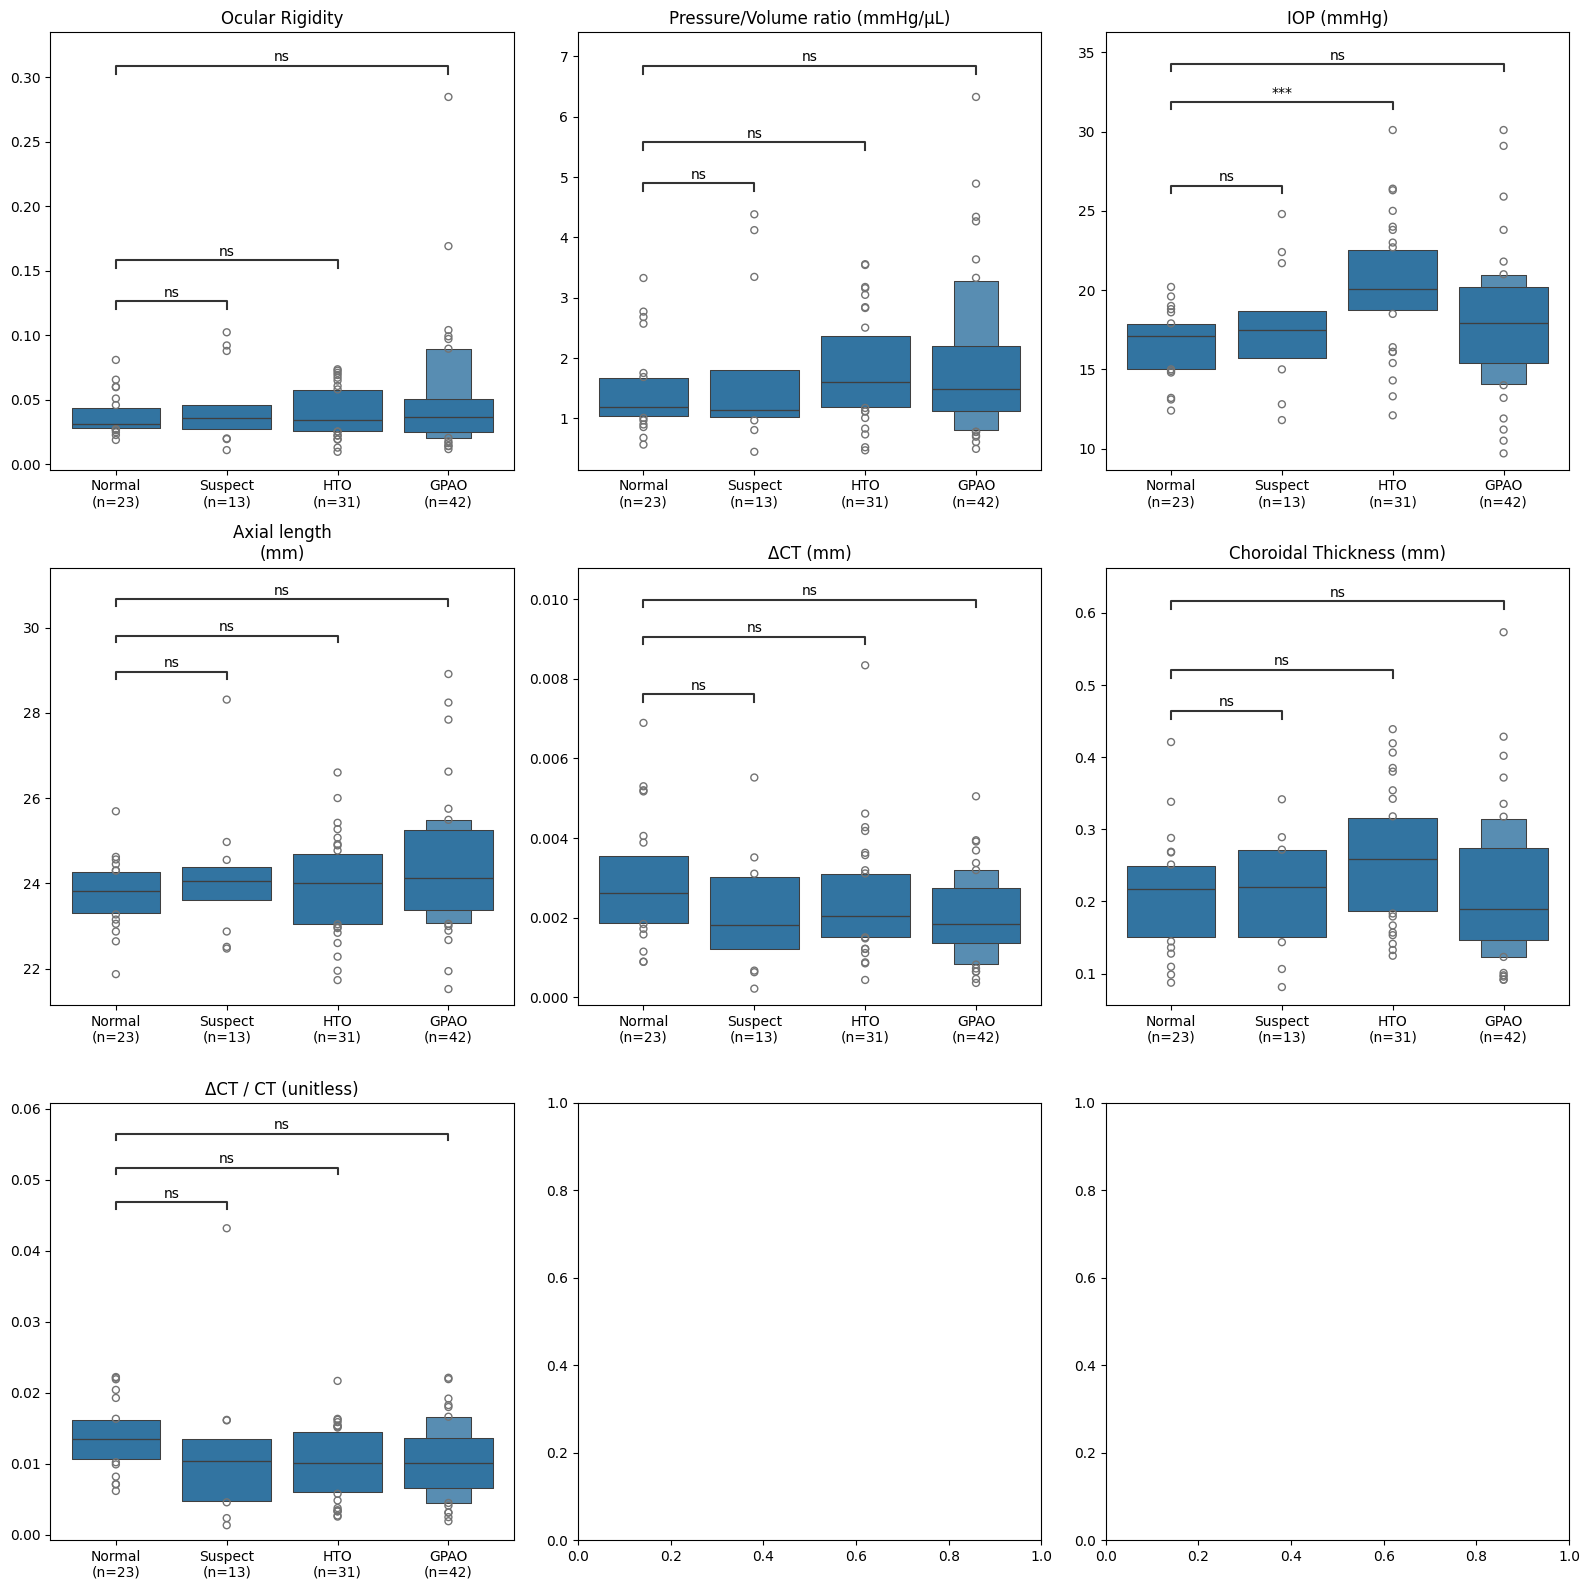

In [15]:
# | label: fig-cross-sectional-study
# | echo: false
# | warning: false

REFERENCE = "Normal"
ORDER = ["Normal", "Suspect", "HTO", "GPAO"]  # severity order, control first
variables_to_test = [
    ("K", "Ocular Rigidity"),
    ("P/V", "Pressure/Volume ratio (mmHg/μL)"),
    ("IOP", "IOP (mmHg)"),
    ("AxialLength", "Axial length\n(mm)"),
    ("deltaCT", "ΔCT (mm)"),
    # ("deltaCT_Mask", "ΔCT (mm)"),
    ("minCT", "Choroidal Thickness (mm)"),
    ("RelativeGrowth", "ΔCT / CT (unitless)"),
]


def compare_to_reference(
    data, var, group="Diagnosis_xs", reference=REFERENCE, order=ORDER
):
    """Mann-Whitney of each group against the control, Holm-corrected per variable.

    Rank-based because half these variables are non-normal at n as low as 11;
    the groups are homoscedastic (Levene n.s.), so a rejection reads as a shift
    in location rather than merely a difference in shape.
    """
    t = data[[group, var]].dropna()
    ref = t.loc[t[group] == reference, var].values
    rows = []
    for g in [g for g in order if g != reference]:
        a = t.loc[t[group] == g, var].values
        if len(a) < 3 or len(ref) < 3:
            continue
        u, p = stats.mannwhitneyu(a, ref, alternative="two-sided")
        rows.append(
            {
                "variable": var,
                "group": g,
                "n": len(a),
                "n_ref": len(ref),
                "median": np.median(a),
                "median_ref": np.median(ref),
                "U": u,
                "p": p,
                "rank_biserial": 2 * u / (len(a) * len(ref)) - 1,
            }
        )
    out = pd.DataFrame(rows)
    if len(out):
        out["p_adj"] = multipletests(out["p"], method="holm")[1]
    return out


results = pd.concat(
    [compare_to_reference(merged, v) for v, _ in variables_to_test], ignore_index=True
)

ncols = 3
nrows = (len(variables_to_test) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 16))
axes = axes.flatten()
for i, (var, label) in enumerate(variables_to_test):
    ax = axes[i]
    sns.boxenplot(data=merged, y=var, x="Diagnosis_xs", order=ORDER, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # counted per panel, not once for the figure: a variable with missing
    # values would otherwise advertise an n its test did not use.
    counts = merged.dropna(subset=[var]).groupby("Diagnosis_xs").size()
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels([f"{g}\n(n={counts.get(g, 0)})" for g in ORDER])

    r = results[results["variable"] == var]
    if len(r):
        pairs = [(REFERENCE, g) for g in r["group"]]
        ann = Annotator(ax, pairs, data=merged, x="Diagnosis_xs", y=var, order=ORDER)
        ann.configure(test=None, text_format="star", loc="inside", verbose=0)
        ann.set_pvalues_and_annotate(r["p_adj"].values)
plt.tight_layout()
plt.show()


In [ ]:
df["Type"].value_counts()


Type
Normal          437
Moderate        321
Early           268
Bleb            209
OHT             177
Suspect         139
Wet              63
Keratoconous     23
Glaucoma         15
Advanced         13
Myopia           11
NTG               2
Name: count, dtype: int64

IndexError: index 6 is out of bounds for axis 0 with size 6

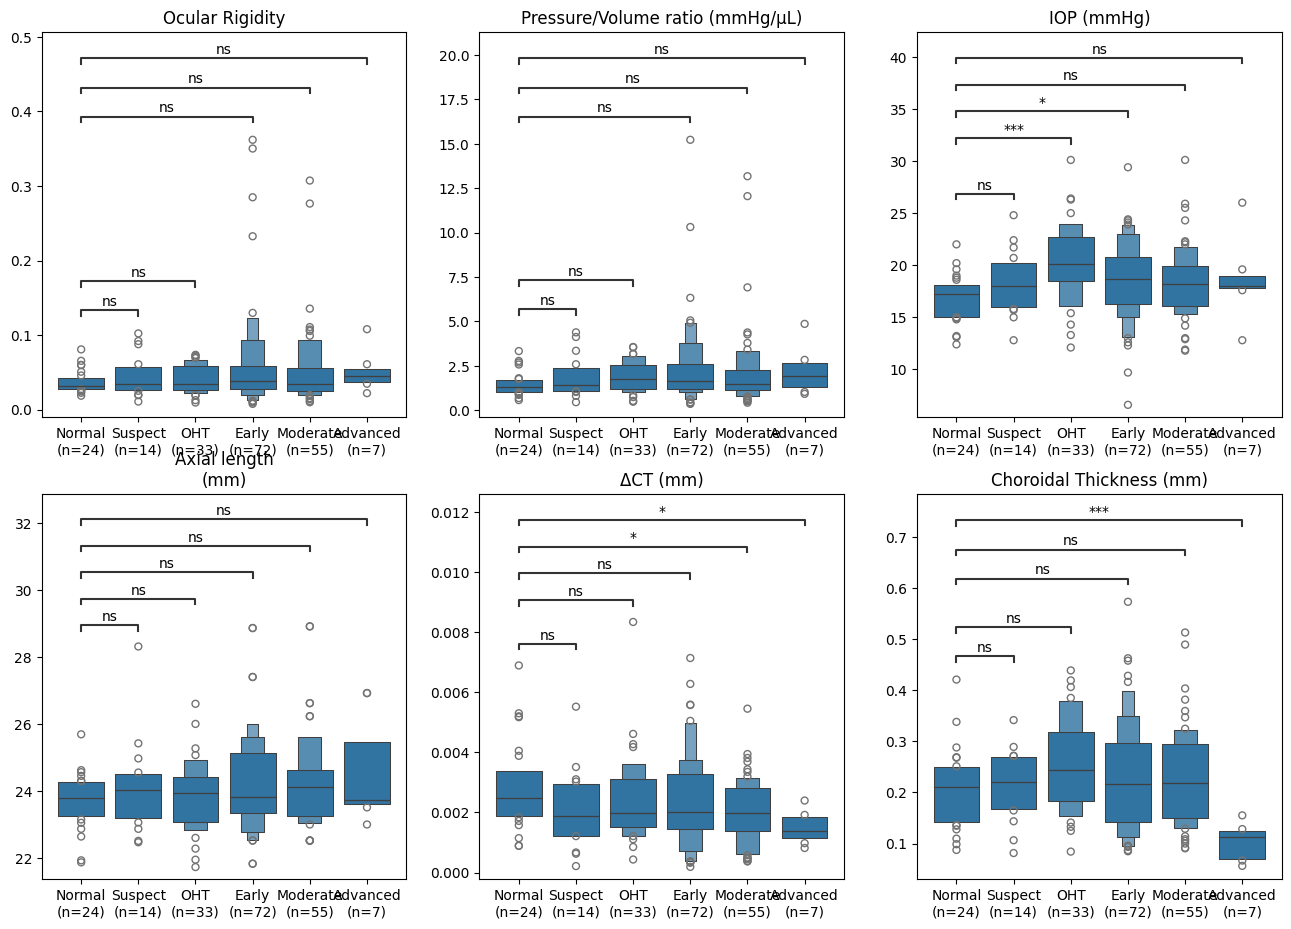

In [ ]:
# | label: fig-cross-sectional-study-severity
# | echo: false
# | warning: false

REFERENCE = "Normal"
ORDER = [
    "Normal",
    "Suspect",
    "OHT",
    "Early",
    "Moderate",
    "Advanced",
]  # severity order, control first
variables_to_test = [
    ("K", "Ocular Rigidity"),
    ("P/V", "Pressure/Volume ratio (mmHg/μL)"),
    ("IOP", "IOP (mmHg)"),
    ("AxialLength", "Axial length\n(mm)"),
    ("deltaCT", "ΔCT (mm)"),
    # ("deltaCT_Mask", "ΔCT (mm)"),
    ("minCT", "Choroidal Thickness (mm)"),
    ("RelativeGrowth", "ΔCT / CT (unitless)"),
]


def compare_to_reference(data, var, group="Type", reference=REFERENCE, order=ORDER):
    """Mann-Whitney of each group against the control, Holm-corrected per variable.

    Rank-based because half these variables are non-normal at n as low as 11;
    the groups are homoscedastic (Levene n.s.), so a rejection reads as a shift
    in location rather than merely a difference in shape.
    """
    t = data[[group, var]].dropna()
    ref = t.loc[t[group] == reference, var].values
    rows = []
    for g in [g for g in order if g != reference]:
        a = t.loc[t[group] == g, var].values
        if len(a) < 3 or len(ref) < 3:
            continue
        u, p = stats.mannwhitneyu(a, ref, alternative="two-sided")
        rows.append(
            {
                "variable": var,
                "group": g,
                "n": len(a),
                "n_ref": len(ref),
                "median": np.median(a),
                "median_ref": np.median(ref),
                "U": u,
                "p": p,
                "rank_biserial": 2 * u / (len(a) * len(ref)) - 1,
            }
        )
    out = pd.DataFrame(rows)
    if len(out):
        out["p_adj"] = multipletests(out["p"], method="holm")[1]
    return out


results = pd.concat(
    [compare_to_reference(df, v) for v, _ in variables_to_test], ignore_index=True
)


ncols = 3
nrows = (len(variables_to_test) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 16))
for i, (var, label) in enumerate(variables_to_test):
    ax = axes[i]
    sns.boxenplot(data=df, y=var, x="Type", order=ORDER, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # counted per panel, not once for the figure: a variable with missing
    # values would otherwise advertise an n its test did not use.
    counts = df.dropna(subset=[var]).groupby("Type").size()
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels([f"{g}\n(n={counts.get(g, 0)})" for g in ORDER])

    r = results[results["variable"] == var]
    if len(r):
        pairs = [(REFERENCE, g) for g in r["group"]]
        ann = Annotator(ax, pairs, data=df, x="Type", y=var, order=ORDER)
        ann.configure(test=None, text_format="star", loc="inside", verbose=0)
        ann.set_pvalues_and_annotate(r["p"].values)
plt.tight_layout()
plt.show()
